In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
DATA_DIR = Path("../Data/raw")
OUTPUT_DIR = Path("../outputs/metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

user_metrics = pd.read_csv(
    OUTPUT_DIR / "user_metrics.csv"
)

sessions = pd.read_csv(
    DATA_DIR / "sessions.csv",
    parse_dates=["session_start", "session_end"]
)

In [3]:
def segment_analysis(
    data,
    segment_column
):

    results = []

    for segment, group_data in data.groupby(
        segment_column
    ):

        control_data = group_data[
            group_data["group"] == "Control"
        ]

        treatment_data = group_data[
            group_data["group"] == "Treatment"
        ]

        if (
            len(control_data) < 100
            or
            len(treatment_data) < 100
        ):
            continue

        c_rate = control_data["converted"].mean()
        t_rate = treatment_data["converted"].mean()

        results.append({
            "segment": segment,
            "control_users": len(control_data),
            "treatment_users": len(treatment_data),
            "control_conversion": c_rate,
            "treatment_conversion": t_rate,
            "absolute_uplift": t_rate - c_rate,
            "relative_uplift":
                (t_rate - c_rate) / c_rate
                if c_rate > 0 else np.nan
        })

    return pd.DataFrame(results)

In [4]:
device_analysis = segment_analysis(
    user_metrics,
    "preferred_device"
)

device_analysis

,segment,control_users,treatment_users,control_conversion,treatment_conversion,absolute_uplift,relative_uplift
0,Desktop,21220,20964,0.264609,0.288733,0.024124,0.091169
1,Mobile,32878,33169,0.269359,0.291688,0.022329,0.082895
2,Tablet,5902,5867,0.265673,0.298108,0.032435,0.122088


In [5]:
premium_analysis = segment_analysis(
    user_metrics,
    "premium_member"
)

In [6]:
country_analysis = segment_analysis(
    user_metrics,
    "country"
)

In [7]:
customer_analysis = segment_analysis(
    user_metrics,
    "customer_type"
)

In [8]:
device_analysis.to_csv(
    OUTPUT_DIR / "device_analysis.csv",
    index=False
)

premium_analysis.to_csv(
    OUTPUT_DIR / "premium_analysis.csv",
    index=False
)

country_analysis.to_csv(
    OUTPUT_DIR / "country_analysis.csv",
    index=False
)

customer_analysis.to_csv(
    OUTPUT_DIR / "customer_analysis.csv",
    index=False
)

In [9]:
first_activity = (
    sessions
    .groupby("user_id")["session_start"]
    .min()
    .reset_index()
)

first_activity.columns = [
    "user_id",
    "first_activity"
]

In [10]:
user_metrics = user_metrics.merge(
    first_activity,
    on="user_id",
    how="left"
)

In [11]:
user_metrics["first_activity"] = pd.to_datetime(
    user_metrics["first_activity"]
)

user_metrics["experiment_week"] = (
    user_metrics["first_activity"]
    .dt.to_period("W")
    .astype(str)
)

In [12]:
weekly_results = (
    user_metrics
    .groupby(
        ["experiment_week", "group"]
    )
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

weekly_results["conversion_rate"] = (
    weekly_results["conversions"]
    /
    weekly_results["users"]
)

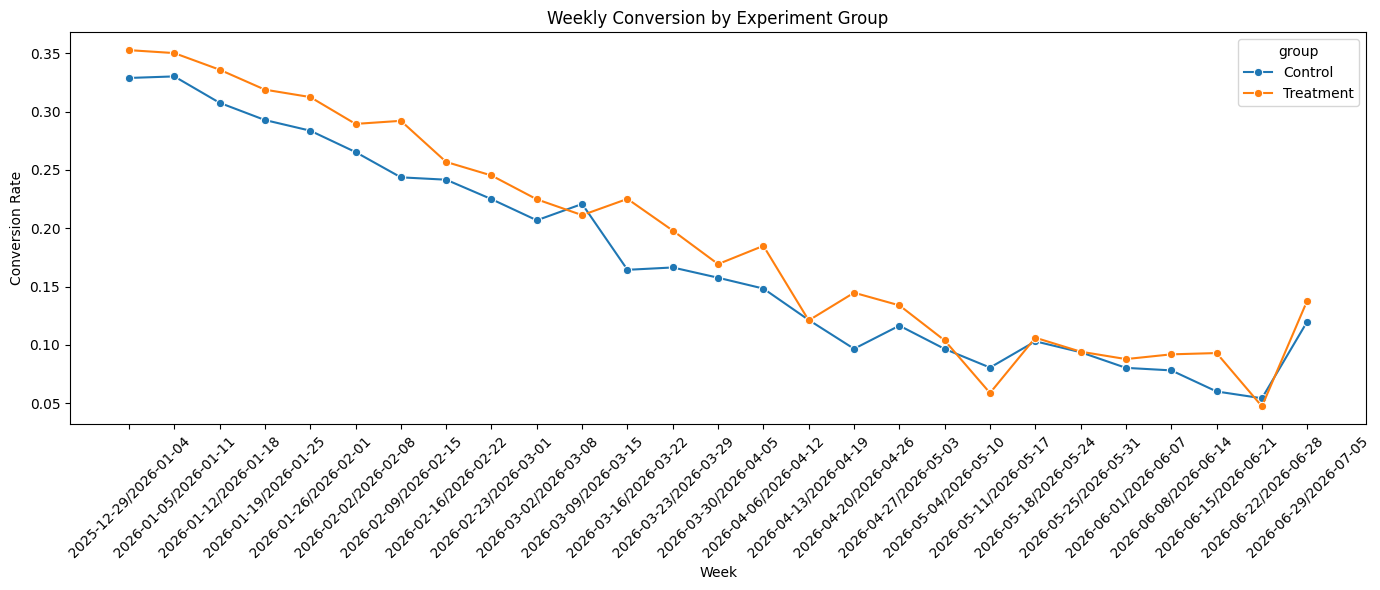

In [13]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=weekly_results,
    x="experiment_week",
    y="conversion_rate",
    hue="group",
    marker="o"
)

plt.xticks(rotation=45)
plt.ylabel("Conversion Rate")
plt.xlabel("Week")
plt.title("Weekly Conversion by Experiment Group")

plt.tight_layout()
plt.show()

In [14]:
weekly_results.to_csv(
    OUTPUT_DIR / "weekly_results.csv",
    index=False
)